In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

In [4]:
weeks_data = pd.date_range("2022-01-01","2023-12-31",freq="D")

n = len(weeks_data)

# searches_series = np.random.normal(500,25,len(weeks_data))

# trend
trend = np.linspace(500, 700, n)


# yearly seasonality
yearly_seasonality = 100 * np.sin(2 * np.pi * np.arange(n) / 365)

# weekly seasonality
weekly_seasonality = 50 * np.sin(2 * np.pi * np.arange(n) / 7)

# noise
noise = np.random.normal(0,30,n)

searches_series = trend + yearly_seasonality + weekly_seasonality + noise


fake_ts_df = pd.DataFrame({'date':weeks_data,'searches':searches_series})

fake_ts_df

,date,searches
0,2022-01-01,514.901425
1,2022-01-02,536.939329
2,2022-01-03,572.167910
3,2022-01-04,573.370095
4,2022-01-05,479.258848
...,...,...
725,2023-12-27,663.092439
726,2023-12-28,644.103334
727,2023-12-29,665.625213
728,2023-12-30,680.090700


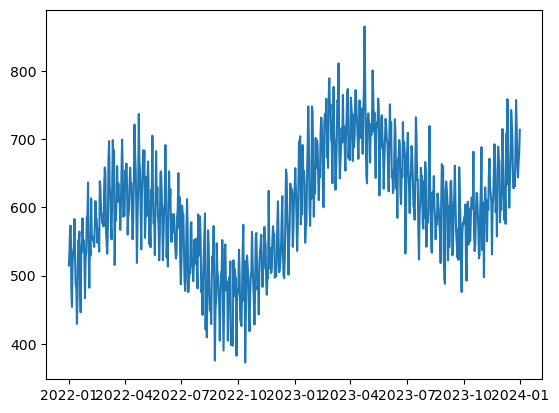

In [5]:
plt.plot(fake_ts_df['date'],fake_ts_df['searches'])

In [6]:
split_date = "2023-07-01"

train = fake_ts_df[fake_ts_df['date'] < split_date]
test = fake_ts_df[fake_ts_df['date'] >= split_date]

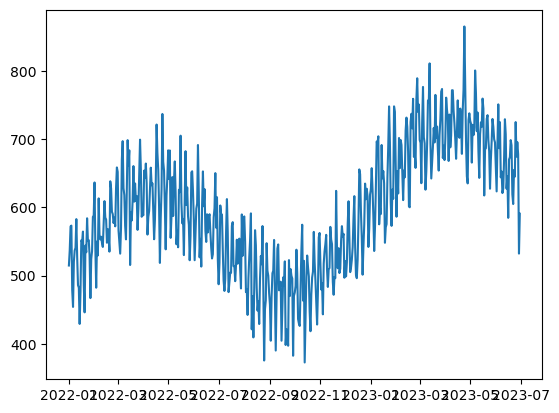

In [7]:
plt.plot(train['date'],train['searches'])

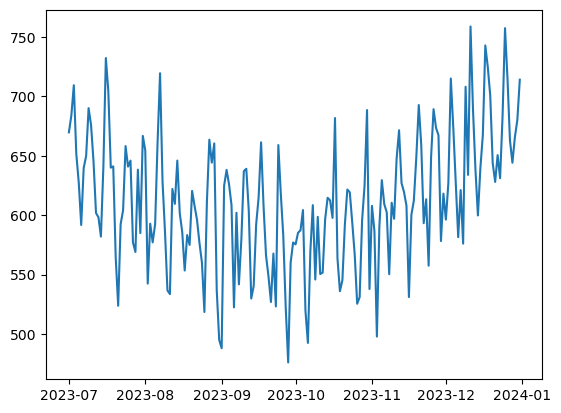

In [8]:
plt.plot(test['date'],test['searches'])

In [9]:
train = train.copy()
train['rolling_mean'] = train['searches'].rolling(window=7).mean()

last_rolling_mean = train['rolling_mean'].dropna().iloc[-1]

test = test.copy()
test['forecast'] = last_rolling_mean

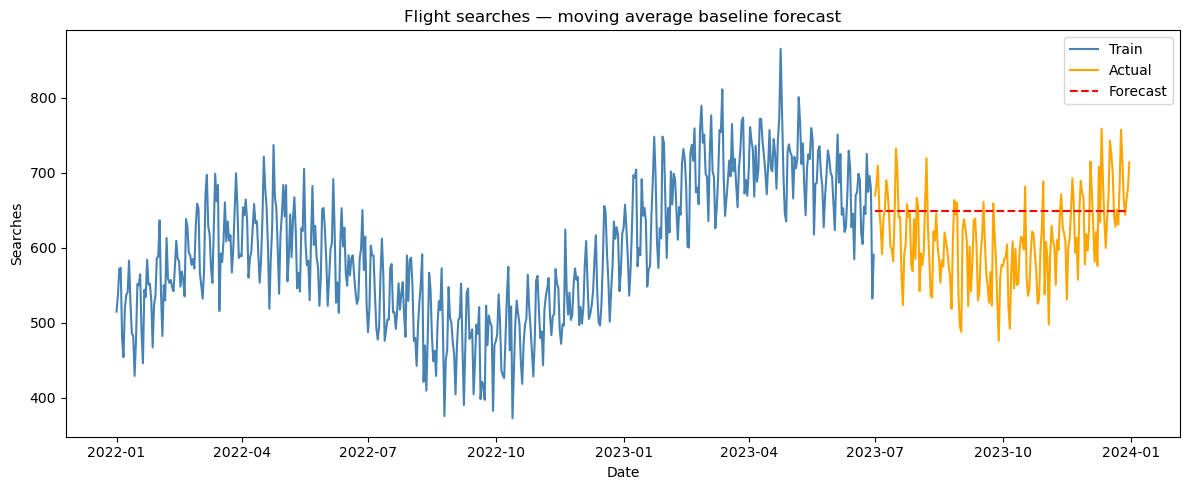

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(train['date'], train['searches'], label='Train', color='steelblue')
plt.plot(test['date'], test['searches'], label='Actual', color='orange')
plt.plot(test['date'], test['forecast'], label='Forecast', color='red', linestyle='--')
plt.legend()
plt.title('Flight searches — moving average baseline forecast')
plt.xlabel('Date')
plt.ylabel('Searches')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(test['searches'], test['forecast'])
mape = mean_absolute_percentage_error(test['searches'], test['forecast'])
rmse = np.sqrt(np.mean((test['searches'] - test['forecast'])**2))

print(f"MAE:  {mae:.1f} searches")
print(f"MAPE: {mape*100:.1f}%")
print(f"RMSE: {rmse:.1f} searches")

MAE:  54.4 searches
MAPE: 9.4%
RMSE: 66.9 searches


In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['searches'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("Series is stationary — good to go")
else:
    print("Series is not stationary — needs differencing")

ADF Statistic: -1.2505
P-value: 0.6515
Series is not stationary — needs differencing


In [13]:
# Difference the series
train_diff = train['searches'].diff().dropna()

# Rerun ADF on differenced series
result_diff = adfuller(train_diff)
print(f"ADF Statistic: {result_diff[0]:.4f}")
print(f"P-value: {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print("Differenced series is stationary — d=1 confirmed")
else:
    print("Still not stationary — consider d=2")

ADF Statistic: -5.4321
P-value: 0.0000
Differenced series is stationary — d=1 confirmed


In [16]:
# np.linspace(500,700,200)

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['searches'],
    order=(1, 1, 1),          # p=1, d=1, q=1
    seasonal_order=(1, 1, 1, 7)  # P=1, D=1, Q=1, s=7 (weekly seasonality)
)

result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                          searches   No. Observations:                  546
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2636.384
Date:                           Fri, 03 Apr 2026   AIC                           5282.767
Time:                                   20:01:50   BIC                           5304.206
Sample:                                        0   HQIC                          5291.153
                                           - 546                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0526      0.052     -1.003      0.316      -0.155       0.050
ma.L1         -0.8159      0.032    -25.325

SARIMA MAPE: 10.6%
Baseline MA MAPE: 11.0%


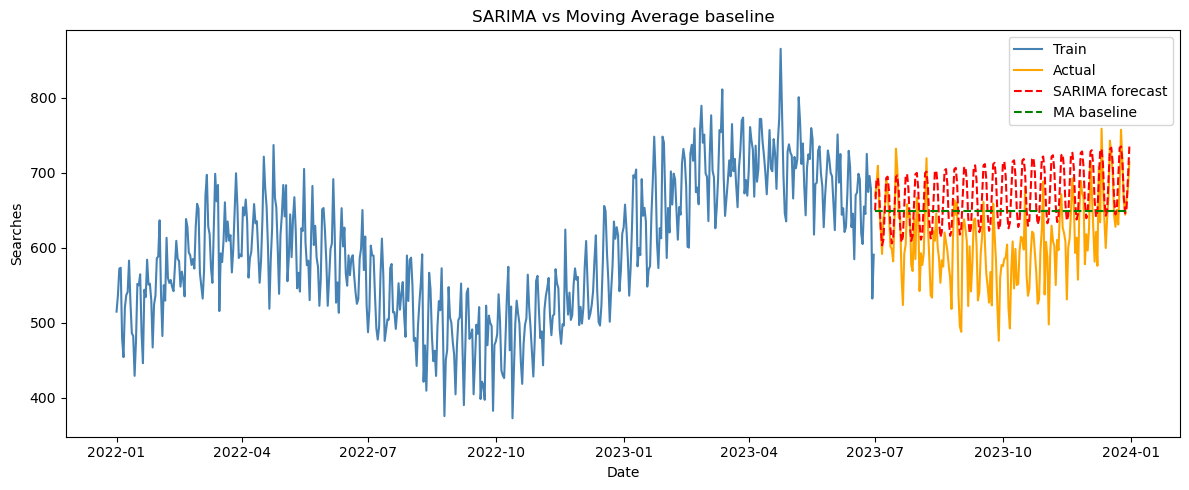

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA
model = SARIMAX(
    train['searches'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

sarima_result = model.fit(disp=False)

# Forecast for the test period
n_forecast = len(test)
forecast = sarima_result.forecast(steps=n_forecast)

# Add forecast to test dataframe
test = test.copy()
test['sarima_forecast'] = forecast.values

# Evaluate
from sklearn.metrics import mean_absolute_percentage_error

mape_sarima = mean_absolute_percentage_error(test['searches'], test['sarima_forecast'])
print(f"SARIMA MAPE: {mape_sarima*100:.1f}%")
print(f"Baseline MA MAPE: 11.0%")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(train['date'], train['searches'], label='Train', color='steelblue')
plt.plot(test['date'], test['searches'], label='Actual', color='orange')
plt.plot(test['date'], test['sarima_forecast'], label='SARIMA forecast', color='red', linestyle='--')
plt.plot(test['date'], test['forecast'], label='MA baseline', color='green', linestyle='--')
plt.legend()
plt.title('SARIMA vs Moving Average baseline')
plt.xlabel('Date')
plt.ylabel('Searches')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Create holiday flags
def create_holiday_features(dates):
    df = pd.DataFrame({'date': dates})
    
    # Christmas effect — 2 weeks before Dec 25
    df['christmas'] = (
        (df['date'].dt.month == 12) & 
        (df['date'].dt.day >= 11)
    ).astype(int)
    
    # Summer effect — July and August
    df['summer'] = (
        df['date'].dt.month.isin([7, 8])
    ).astype(int)
    
    return df[['christmas', 'summer']]

train_exog = create_holiday_features(train['date'])
test_exog = create_holiday_features(test['date'])

# Fit SARIMAX with holiday features
model = SARIMAX(
    train['searches'],
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

sarima_result = model.fit(disp=False)
forecast = sarima_result.forecast(steps=len(test), exog=test_exog)

test = test.copy()
test['sarimax_forecast_exo'] = forecast.values

mape_sarimax = mean_absolute_percentage_error(test['searches'], test['sarimax_forecast'])
print(f"SARIMAX MAPE: {mape_sarimax*100:.1f}%")
print(f"SARIMA MAPE:  10.6%")
print(f"MA baseline:  11.0%")

SARIMAX MAPE: 10.0%
SARIMA MAPE:  10.6%
MA baseline:  11.0%


In [26]:
test['sarimax_forecast_exo']

546    631.404384
547    673.297326
548    674.476001
549    655.179121
550    608.007410
          ...    
725    667.872510
726    646.032779
727    653.420910
728    692.708567
729    735.179463
Name: sarimax_forecast_exo, Length: 184, dtype: float64

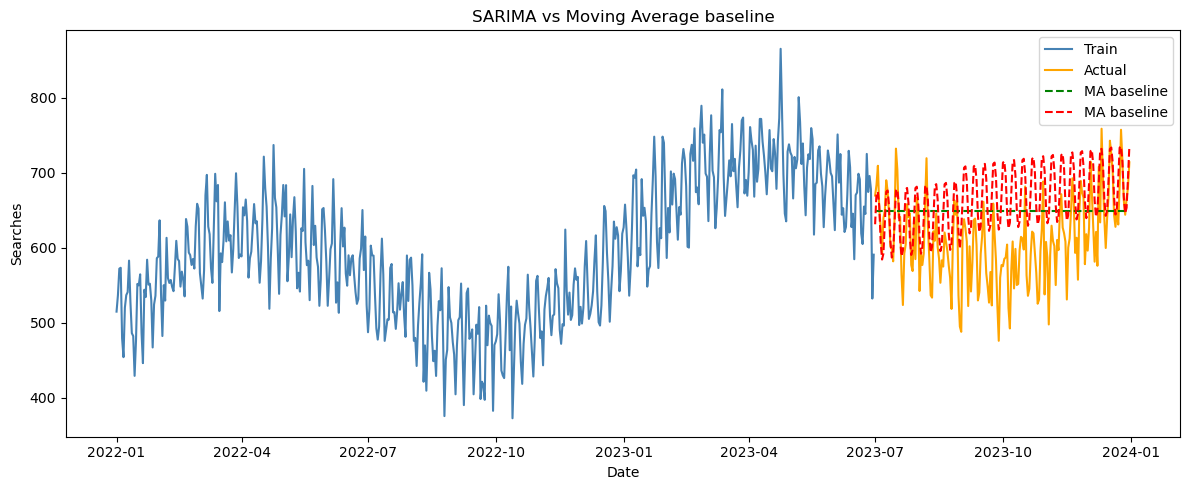

In [28]:
# train_exog
plt.figure(figsize=(12, 5))
plt.plot(train['date'], train['searches'], label='Train', color='steelblue')
plt.plot(test['date'], test['searches'], label='Actual', color='orange')
# plt.plot(test['date'], test['sarima_forecast'], label='SARIMA forecast', color='red', linestyle='--')
plt.plot(test['date'], test['forecast'], label='MA baseline', color='green', linestyle='--')
plt.plot(test['date'], test['sarimax_forecast_exo'], label='MA baseline', color='red', linestyle='--')
plt.legend()
plt.title('SARIMA vs Moving Average baseline')
plt.xlabel('Date')
plt.ylabel('Searches')
plt.tight_layout()
plt.show()